In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from helper_function import plot_decision_boundary, accuracy_fn


In [3]:
n_samples = 1000
number_classes = 4
n_features = 2
random_state = 2026

x_blob, y_blob = make_blobs(n_samples, centers=number_classes, cluster_std=1.2, random_state=2026)
x_blob, y_blob = torch.from_numpy(x_blob).type(torch.float), torch.from_numpy(y_blob).type(torch.float)

x_train, x_test, y_train, y_test = train_test_split(x_blob, y_blob, test_size=0.2, random_state=2026)


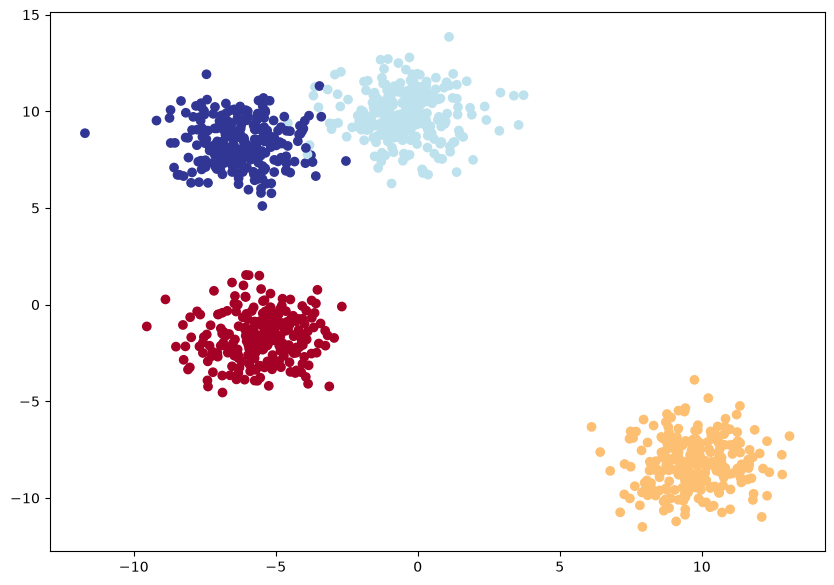

In [4]:
plt.figure(figsize=(10,7))
plt.scatter(x_blob[:, 0], x_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

In [36]:
# training model

class Blobs(nn.Module):

    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=8)
        self.layer2 = nn.Linear(in_features=8, out_features=8)
        self.layer3 = nn.Linear(in_features=8, out_features=4)
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.relu(self.layer1(x))
        z = self.relu(self.layer2(z))
        z = self.layer3(z)
        return z

In [34]:
# instiating model and manual_seed (to make weight and bias does changes randomly each time we run it)
torch.manual_seed(random_state)
model = Blobs()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(params=model.parameters(), lr=0.1)
# y_preds = model(x_train)
# y_preds
# torch.softmax(y_preds, dim=1).argmax(dim=1)
# y_train


In [35]:
# training model

epochs = 10000
y_train = y_train.type(torch.long)
y_test = y_test.type(torch.long)

for epoch in range(epochs):
    model.train()
    y_logits = model(x_train)
    y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)
    loss = loss_fn(y_logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    acc_train = accuracy_fn(y_train , y_preds)

    model.eval()
    with torch.inference_mode():
        test_logits = model(x_test)
        test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_loss = loss_fn(test_logits, y_test)

        acc_test = accuracy_fn(y_test, test_preds)

    if epoch % 10 == 0:
        print(f"Epoch:{epoch} | loss_train:{loss} | acc_train:{acc_train:.2f}% | loss_test:{test_loss} | acc_test:{acc_test:.2f}%")
    


Epoch:0 | loss_train:1.6901339292526245 | acc_train:24.88% | loss_test:2.0443503856658936 | acc_test:69.00%
Epoch:10 | loss_train:0.6844062209129333 | acc_train:75.62% | loss_test:1.17469322681427 | acc_test:74.50%
Epoch:20 | loss_train:0.6000294089317322 | acc_train:74.88% | loss_test:0.5774314403533936 | acc_test:82.00%
Epoch:30 | loss_train:0.02488059550523758 | acc_train:99.38% | loss_test:0.02705678716301918 | acc_test:99.50%
Epoch:40 | loss_train:0.019422169774770737 | acc_train:99.38% | loss_test:0.0230764988809824 | acc_test:99.50%
Epoch:50 | loss_train:0.01820392534136772 | acc_train:99.38% | loss_test:0.021953564137220383 | acc_test:99.50%
Epoch:60 | loss_train:0.017706817016005516 | acc_train:99.38% | loss_test:0.02144317887723446 | acc_test:99.50%
Epoch:70 | loss_train:0.01744113862514496 | acc_train:99.38% | loss_test:0.021152712404727936 | acc_test:99.50%
Epoch:80 | loss_train:0.01727268286049366 | acc_train:99.38% | loss_test:0.020956093445420265 | acc_test:99.50%
Epoch:

In [38]:
# 8.4 Getting prediction probabilities for a multi-class PyTorch model
# In order to evaluate and train and test our model, we need to convert our model's outputs (logtis) to predicition probabilities and then to
# prediction labels.
# Logits (raw outp|ut of the model) -> Pred probs (use torch. softmax) -> Pred labels (take the argmax of the prediction probabilities)

In [ ]:
# torch.manual_seed(2026)
# x = torch.randint(0, 10, size=(2,2,3))
# print(x.shape)
# print(x)
# x.max(dim=2)

In [ ]:
#  i guess sth right if dim-max -> = ndim - 1
#  for 2d -> dim < 2, dim = 0 means comparing the row with the each other moving down, so if the dim = 1 so correcting each
# column on each row.
# this is the logic: if the dim count does got to the column number itself it means compare each column per row

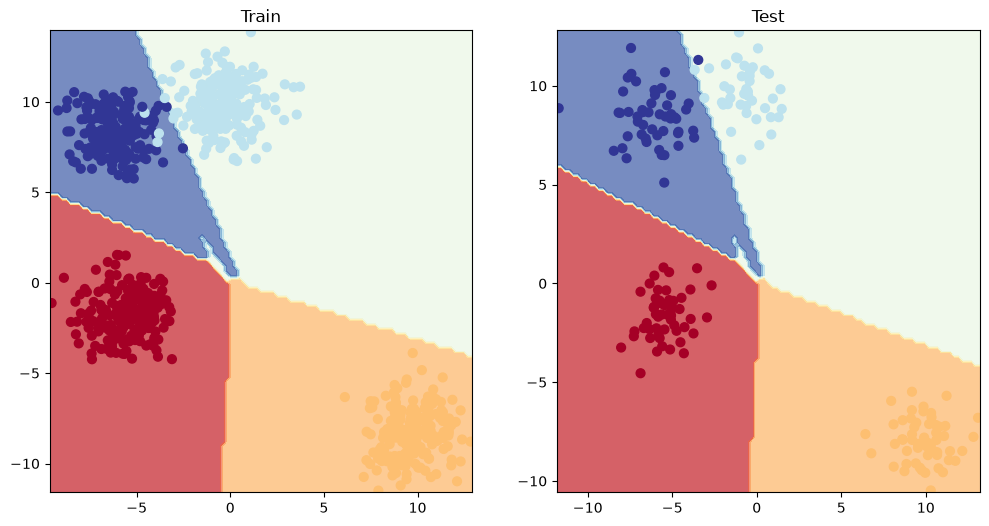

In [39]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2,1)
plt.title("Train")
plot_decision_boundary(model, x_train, y_train)
plt.subplot(1, 2,2)
plt.title("Test")
plot_decision_boundary(model, x_test, y_test)

In [ ]:
 ## 9. A few more classification metrics ... (to evaluate our classification model)

# * Accuracy - out of 100 samples, how many does our model get right?
# * Precision
# * Recall
# * F1-score
# * Confusion matrix
# * Classification report